# QQ Plot Analysis — 

This notebook demonstrates how to compare sample data against theoretical distributions using density plots and QQ plots.

**Key objective:** check whether the data behaves like a selected distribution by comparing its quantiles with theoretical quantiles.


## 1. Import required libraries

The first step is to load the core Python libraries needed for numerical computation, tabular data handling, and visualization.


In [12]:
# Import NumPy for numerical operations such as random sampling and percentile calculation.
import numpy as np

# Import Pandas for working with tabular data structures such as DataFrames.
import pandas as pd

# Import Seaborn for statistical visualization and for loading the built-in Iris dataset.
import seaborn as sns


## 2. Load the Iris dataset

The Iris dataset is loaded from Seaborn. In this notebook, the `sepal_length` column is used as the main sample variable for distribution comparison.


In [13]:
# Load the built-in Iris dataset into a Pandas DataFrame.
df = sns.load_dataset('iris')

# The DataFrame contains flower measurements such as sepal length, sepal width, petal length, and petal width.
# In the next steps, we focus on df['sepal_length'] as the observed sample data.


## 3. Visualize the distribution of sepal length

A KDE plot gives a smooth estimate of the probability density of `sepal_length`. This helps us visually inspect the shape of the data before applying a QQ plot.


<Axes: xlabel='sepal_length', ylabel='Density'>

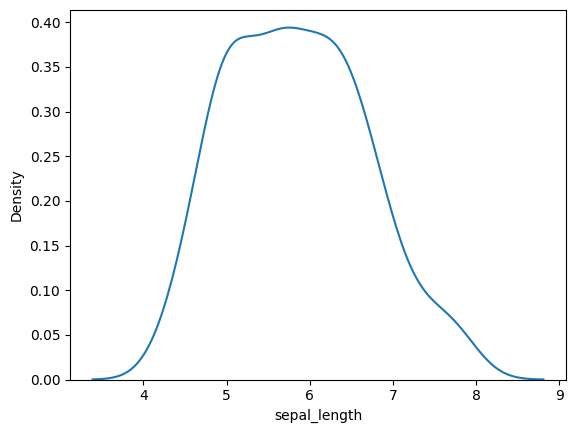

In [14]:
# Create a Kernel Density Estimate plot for the sepal_length column.
# KDE smooths the distribution, making it easier to observe the overall shape of the data.
sns.kdeplot(df['sepal_length'])


### Result / plot interpretation

The KDE plot shows the empirical distribution of `sepal_length`. If the curve looks symmetric and bell-shaped, the data may be roughly normal. If it is skewed, multi-peaked, or has heavy tails, then a normal distribution may not be a strong fit. This plot is a preliminary check; the QQ plot later gives a more direct quantile-based diagnostic.


## 4. Sort the observed sample values

QQ plots compare quantiles. Sorting the observed values prepares the data for percentile/quantile calculation.


In [15]:
# Convert the sepal_length column from the DataFrame into a Python list.
# Sorting arranges the values from smallest to largest, which is required for quantile-based comparison.
temp = sorted(df['sepal_length'].tolist())


## 5. Calculate observed data quantiles

Here, percentile values from the Iris `sepal_length` data are calculated. These will become the observed/sample quantiles on the QQ-style scatter plot.


In [16]:
# Create an empty list to store percentiles calculated from the observed sepal_length values.
y_quant = []

# Loop through percentiles from 1% to 100%.
for i in range(1, 101):
    # Calculate the i-th percentile of the sorted sepal_length data.
    # Each value represents a sample quantile from the observed dataset.
    y_quant.append(np.percentile(temp, i))


## 6. Generate theoretical normal data

A random sample is generated from a standard normal distribution. Its quantiles will be compared against the Iris `sepal_length` quantiles.


In [17]:
# Generate 1000 random values from a normal distribution.
# loc=0 means the distribution has mean 0.
# scale=1 means the distribution has standard deviation 1.
# size=1000 means 1000 random observations are generated.
samples = np.random.normal(loc=0, scale=1, size=1000)


## 7. Calculate theoretical normal quantiles

The same percentile levels are calculated from the generated normal sample. These values serve as approximate theoretical quantiles from a normal distribution.


In [18]:
# Create an empty list to store percentiles from the generated normal sample.
x_quant = []

# Loop through percentiles from 1% to 100%.
for i in range(1, 101):
    # Calculate the i-th percentile of the generated normal data.
    # These values act as theoretical normal quantiles for comparison.
    x_quant.append(np.percentile(samples, i))


## 8. Manually create a QQ-style scatter plot

This scatter plot compares theoretical normal quantiles on the x-axis with observed Iris `sepal_length` quantiles on the y-axis.


<Axes: >

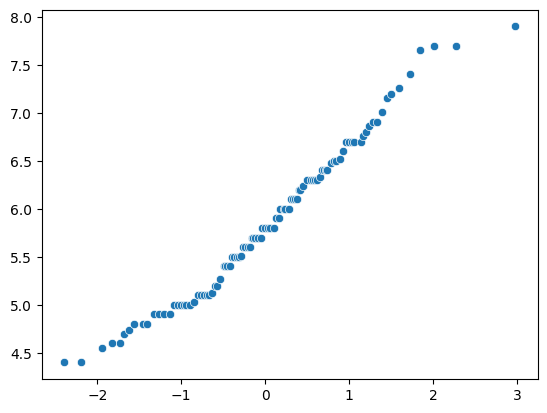

In [19]:
# Create a scatter plot between normal-distribution quantiles and observed sepal_length quantiles.
# x_quant represents quantiles from the generated normal distribution.
# y_quant represents quantiles from the actual sepal_length data.
# If the relationship is close to a straight line, the observed data is approximately normal.
sns.scatterplot(x=x_quant, y=y_quant)


### Result / plot interpretation

The points compare the quantiles of normal data against the quantiles of `sepal_length`. A near-linear pattern suggests that `sepal_length` is reasonably close to normal after accounting for differences in mean and spread. Clear curvature or systematic deviation from a straight-line pattern would indicate non-normal behavior, especially in the tails.


## 9. Create a QQ plot using Statsmodels

Instead of manually computing quantiles, `statsmodels` provides `qqplot`, which directly compares sample data against a theoretical normal distribution.


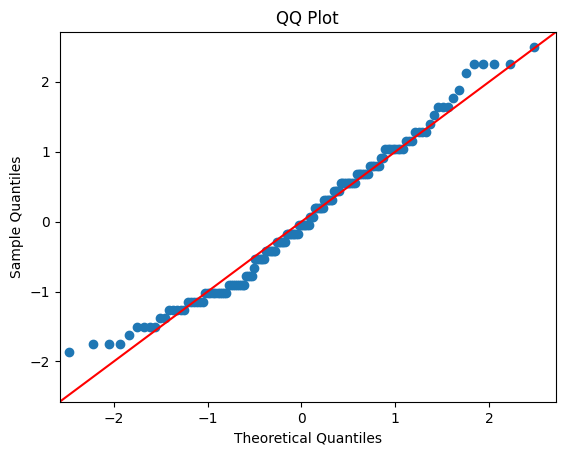

In [20]:
# This section uses the statsmodels library to create a standard QQ plot.
# A QQ plot compares the quantiles of sample data against the quantiles of a theoretical distribution.

# Import Statsmodels, which provides the qqplot function.
import statsmodels.api as sm

# Import Matplotlib for adding plot titles, axis labels, and displaying the figure.
import matplotlib.pyplot as plt

# Create a QQ plot for the sepal_length data.
# line='45' draws a 45-degree reference line.
# fit=True estimates the mean and standard deviation from the data before comparison.
fig = sm.qqplot(df['sepal_length'], line='45', fit=True)

# Add a title to explain what the plot represents.
plt.title('QQ Plot')

# Label the x-axis as theoretical quantiles from the normal distribution.
plt.xlabel('Theoretical Quantiles')

# Label the y-axis as sample quantiles from the sepal_length data.
plt.ylabel('Sample Quantiles')

# Display the completed QQ plot.
plt.show()


### Result / QQ plot interpretation

This plot checks whether `sepal_length` follows a normal distribution. If most points fall close to the 45-degree reference line, the normal assumption is acceptable. Deviations at the lower or upper ends indicate tail differences, meaning the smallest or largest observed values do not perfectly match what a normal distribution would predict. For this dataset, the visual pattern should be treated as approximately normal rather than perfectly normal.


## 10. Generate uniform random data

The next section switches from Iris data to synthetic data generated from a uniform distribution. This allows us to test whether a QQ plot correctly identifies data that follows a uniform distribution.


In [22]:
# Import NumPy again for numerical operations and random number generation.
# This repeat import is not harmful, but in a cleaner notebook it could be removed because NumPy was already imported earlier.
import numpy as np

# Import SciPy statistics tools for fitting and defining probability distributions.
import scipy.stats as stats

# Import Statsmodels again for QQ plotting.
# This repeat import is also not harmful, but it is redundant because Statsmodels was already imported above.
import statsmodels.api as sm

# Import Matplotlib again for plot formatting and display.
# This repeat import is redundant but does not affect the notebook output.
import matplotlib.pyplot as plt

# Generate 1000 random values from a uniform distribution between 0 and 1.
# low=0 sets the minimum possible value.
# high=1 sets the maximum possible value.
# size=1000 creates 1000 random observations.
x = np.random.uniform(low=0, high=1, size=1000)


## 11. Fit a uniform distribution to the generated data

The uniform distribution parameters are estimated from the generated sample. This fitted distribution is then used as the theoretical comparison distribution in the QQ plot.


In [23]:
# Estimate the parameters of a uniform distribution from the generated data x.
# stats.uniform.fit returns the location and scale parameters.
# For an ideal Uniform(0, 1), loc should be close to 0 and scale should be close to 1.
params = stats.uniform.fit(x)

# Create a frozen uniform distribution object using the fitted parameters.
# loc=params[0] defines the starting point of the fitted uniform distribution.
# scale=params[1] defines the width/range of the fitted uniform distribution.
dist = stats.uniform(loc=params[0], scale=params[1])


## 12. Create a QQ plot for uniform data against a fitted uniform distribution

This QQ plot compares the generated uniform sample against the fitted uniform distribution.


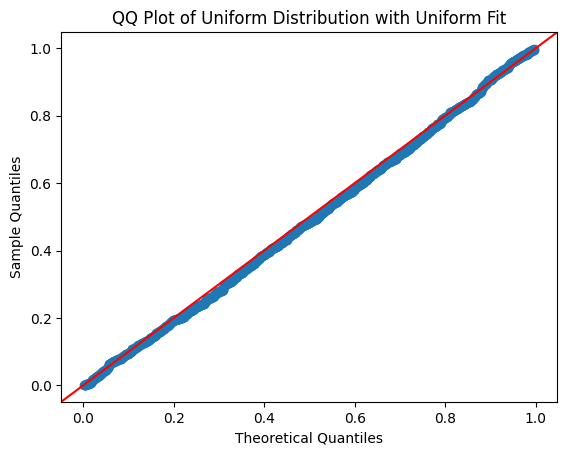

In [24]:
# Create a QQ plot of the generated data x against the fitted uniform distribution.
# dist=dist tells statsmodels to compare x with the fitted uniform distribution instead of the default normal distribution.
# line='45' adds a reference line; points close to this line indicate a good fit.
fig = sm.qqplot(x, dist=dist, line='45')

# Add a title that describes the distribution being tested.
plt.title('QQ Plot of Uniform Distribution with Uniform Fit')

# Label the x-axis as theoretical quantiles from the fitted uniform distribution.
plt.xlabel('Theoretical Quantiles')

# Label the y-axis as sample quantiles from the generated uniform data.
plt.ylabel('Sample Quantiles')

# Display the final QQ plot.
plt.show()


### Result / QQ plot interpretation

Because the sample `x` was generated from a uniform distribution and then compared against a fitted uniform distribution, the points should lie close to the 45-degree line. Small deviations are expected because random sampling introduces noise. Large systematic curves would suggest that the fitted distribution does not match the data, but in this case the QQ plot should confirm that the uniform model is appropriate.


## Final conclusion

This notebook demonstrates two distribution-checking workflows:

1. **Iris `sepal_length` vs. normal distribution:** useful for checking whether a real dataset is approximately normal.
2. **Synthetic uniform data vs. fitted uniform distribution:** useful for validating that QQ plots correctly show a strong fit when the data truly comes from the tested distribution.

Overall, QQ plots are more diagnostic than basic density plots because they directly compare sample quantiles with theoretical quantiles. The closer the points are to the reference line, the stronger the distributional fit.
